# Double Post-LASSO Regression
## Causal Effect of Scholarship on Student Dropout

### PICO Framework

| Component | Description |
|-----------|-------------|
| **Population** | Higher education students from Portugal |
| **Intervention** | Being a scholarship holder |
| **Control** | Students without scholarship, with similar socio-demographic & academic characteristics |
| **Outcome** | Dropout (binary: 1 = Dropout, 0 = Enrolled/Graduate) |

**Hypothesis:** Receiving a scholarship has a **negative** effect on the probability of dropout.

---

### Methodological Rationale — Why Double Post-LASSO?

The causal DAG reveals a high-dimensional confounding structure: socio-demographic, academic, and macroeconomic variables all confound the `Scholarship holder → Dropout` path.

**Double Post-LASSO** (Belloni, Chernozhukov & Hansen, 2014) solves the variable selection problem in a way that is valid for causal inference:

1. LASSO of **Treatment** on controls → $S_T$ (variables that predict scholarship)
2. LASSO of **Outcome** on controls → $S_Y$ (variables that predict dropout)
3. **Union** $S = S_T \cup S_Y$ as the control set
4. **OLS** of Outcome on Treatment + $S$ → unbiased $\hat{\beta}_T$

This avoids the omitted-variable bias of manual selection and the post-selection inference problem of a single LASSO.

> **DAG constraint:** `Debtor` and `Tuition fees up to date` are **mediators** on the path Scholarship → Financial Constraints → Dropout. They are excluded from all control sets to avoid post-treatment bias.

## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

Libraries loaded.


## 2. Data Loading & Preprocessing

In [121]:
df = pd.read_csv('data.csv', sep=';')

# Strip trailing whitespace/tabs from column names (artefact of the raw dataset)
df.columns = df.columns.str.strip()

# Binarize outcome: 1 = Dropout, 0 = Enrolled or Graduate
df['dropout'] = (df['Target'] == 'Dropout').astype(int)

print(f"Dataset shape : {df.shape}")
print(f"\nTarget distribution:")
print(df['Target'].value_counts())
print(f"\nDropout rate  : {df['dropout'].mean():.3f}")
print(f"Scholarship   : {df['Scholarship holder'].mean():.3f}")

Dataset shape : (4424, 38)

Target distribution:
Graduate    2209
Dropout     1421
Enrolled     794
Name: Target, dtype: int64

Dropout rate  : 0.321
Scholarship   : 0.248


## 3. Variable Definitions

We define three groups of controls based on the DAG:
- **Socio-demographic**: confound both scholarship assignment and dropout risk
- **Academic**: predict dropout; some also predict scholarship eligibility  
- **Macroeconomic**: affect scholarship availability and dropout risk

**Excluded mediators**: `Debtor` and `Tuition fees up to date` lie on the causal path  
Scholarship → Financial Constraints → Dropout. Including them would block part of the indirect effect.

In [ ]:
treatment = 'Scholarship holder'
outcome   = 'dropout'

socio_demo = [
    'Marital status',
    "Mother's qualification", "Father's qualification",
    "Mother's occupation",    "Father's occupation",
    'Nacionality', 'Gender', 'Age at enrollment',
    'Displaced', 'Educational special needs', 'International',
]

academic = [
    'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance',
    'Previous qualification', 'Previous qualification (grade)',
    'Admission grade',
    'Curricular units 1st sem (credited)',   'Curricular units 2nd sem (credited)',
    'Curricular units 1st sem (enrolled)',   'Curricular units 2nd sem (enrolled)',
    'Curricular units 1st sem (evaluations)','Curricular units 2nd sem (evaluations)',
    'Curricular units 1st sem (approved)',   'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (grade)',      'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (without evaluations)',
]

macro = ['Unemployment rate', 'Inflation rate', 'GDP']

# EXCLUDED mediators: ['Debtor', 'Tuition fees up to date']
all_controls = socio_demo + academic + macro

Controls — socio-demo: 11 | academic: 19 | macro: 3
Total controls: 33 | Excluded mediators: Debtor, Tuition fees up to date


## 4. Feature Engineering

**Key choices:**
- Categorical variables with many levels (Course, Application mode, etc.) are one-hot encoded with `drop_first=True` to avoid perfect multicollinearity.
- Variables that are already binary or ordinal are left as-is.
- All features are standardised (mean 0, std 1) before LASSO to ensure penalisation is applied equally across variables.

In [ ]:
# Select working sample
cols_needed = [treatment, outcome] + all_controls
data = df[cols_needed].dropna().copy()
data = data.reset_index(drop=True)

X_raw = data[all_controls].copy()
T = data[treatment].values.astype(float)
Y = data[outcome].values.astype(float)

# High-cardinality categoricals → one-hot encode
# Ordinal / already-numeric variables → keep as-is
categorical_cols = [
    'Marital status',
    "Mother's qualification", "Father's qualification",
    "Mother's occupation",    "Father's occupation",
    'Nacionality', 'Application mode', 'Application order', 'Course',
]
X_raw[categorical_cols] = X_raw[categorical_cols].astype('category')

X_enc = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)
print(f"Shape after one-hot encoding: {X_enc.shape}")

# Standardise
scaler = StandardScaler()
X_scaled_arr = scaler.fit_transform(X_enc)
X_scaled_df  = pd.DataFrame(X_scaled_arr, columns=X_enc.columns)

# Drop near-zero-variance columns (would cause singular matrices in logit)
var_mask = X_scaled_df.var() > 1e-6
dropped_cols = X_scaled_df.columns[~var_mask].tolist()
if dropped_cols:
    print(f"Dropped {len(dropped_cols)} near-zero-variance columns: {dropped_cols}")
X_scaled_df = X_scaled_df.loc[:, var_mask]

# Also remove perfectly collinear columns via correlation matrix
corr_matrix = X_scaled_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.999)]
if to_drop_corr:
    print(f"Dropped {len(to_drop_corr)} perfectly collinear columns: {to_drop_corr}")
    X_scaled_df = X_scaled_df.drop(columns=to_drop_corr)

X_scaled     = X_scaled_df.values
feature_names = X_scaled_df.columns.tolist()

print(f"Final feature matrix: {X_scaled.shape[0]} obs × {X_scaled.shape[1]} features")

Shape after one-hot encoding: (4424, 226)
Dropped 2 perfectly collinear columns: ["Father's qualification_18", "Father's occupation_124"]
Final feature matrix: 4424 obs × 224 features
Treatment (Scholarship holder): 1099 / 4424  (0.248)
Outcome   (Dropout)           : 1421 / 4424  (0.321)


## 5. Double Post-LASSO — Variable Selection

We implement the **Belloni et al. (2014) plug-in penalty**:

$$\alpha = c \cdot \hat{\sigma} \cdot \sqrt{\frac{\log(p)}{n}}$$

where:
- $c = 1.1$ (recommended constant)
- $\hat{\sigma}$ is estimated from the OLS residuals of each first-stage regression
- $p$ = number of features, $n$ = number of observations

This penalty is calibrated to the scale of each regression, producing theoretically justified sparsity rather than CV-minimised prediction error.

In [124]:
from sklearn.linear_model import Lasso

n, p = X_scaled.shape
c = 1.1  # Belloni recommended constant

def belloni_alpha(X, y, c, n, p):
    """Compute plug-in Belloni alpha: c * sigma_hat * sqrt(log(p)/n)."""
    ols_coef, _, _, _ = np.linalg.lstsq(np.c_[np.ones(n), X], y, rcond=None)
    residuals = y - np.c_[np.ones(n), X] @ ols_coef
    sigma_hat = np.std(residuals, ddof=p + 1)
    return c * sigma_hat * np.sqrt(np.log(p) / n), sigma_hat

# ── Step 1: LASSO(T ~ X) ───────────────────────────────────────────────────
print("=" * 60)
print("STEP 1 — LASSO: Treatment (Scholarship) ~ Controls")
print("=" * 60)

alpha_T, sigma_T = belloni_alpha(X_scaled, T, c, n, p)
print(f"  n={n}, p={p} | sigma_T={sigma_T:.4f} | alpha_T={alpha_T:.6f}")

lasso_T = Lasso(alpha=alpha_T, max_iter=20000, fit_intercept=True)
lasso_T.fit(X_scaled, T)

coef_T      = lasso_T.coef_
selected_T  = [feature_names[i] for i in np.where(coef_T != 0)[0]]
print(f"  → {len(selected_T)} / {p} variables selected\n")
for v in selected_T:
    print(f"     • {v:55s} coef = {coef_T[feature_names.index(v)]:+.4f}")

# ── Step 2: LASSO(Y ~ X) ───────────────────────────────────────────────────
print()
print("=" * 60)
print("STEP 2 — LASSO: Outcome (Dropout) ~ Controls")
print("=" * 60)

alpha_Y, sigma_Y = belloni_alpha(X_scaled, Y, c, n, p)
print(f"  n={n}, p={p} | sigma_Y={sigma_Y:.4f} | alpha_Y={alpha_Y:.6f}")

lasso_Y = Lasso(alpha=alpha_Y, max_iter=20000, fit_intercept=True)
lasso_Y.fit(X_scaled, Y)

coef_Y      = lasso_Y.coef_
selected_Y  = [feature_names[i] for i in np.where(coef_Y != 0)[0]]
print(f"  → {len(selected_Y)} / {p} variables selected\n")
for v in selected_Y:
    print(f"     • {v:55s} coef = {coef_Y[feature_names.index(v)]:+.4f}")

# ── Step 3: Union ──────────────────────────────────────────────────────────
print()
print("=" * 60)
print("STEP 3 — Union S = S_T ∪ S_Y")
print("=" * 60)

only_T        = set(selected_T) - set(selected_Y)
only_Y        = set(selected_Y) - set(selected_T)
both          = set(selected_T) & set(selected_Y)
union_selected = list(set(selected_T) | set(selected_Y))

print(f"  In S_T only : {len(only_T)}")
print(f"  In S_Y only : {len(only_Y)}")
print(f"  In both     : {len(both)}")
print(f"  Union total : {len(union_selected)}")

STEP 1 — LASSO: Treatment (Scholarship) ~ Controls
  n=4424, p=224 | sigma_T=0.3905 | alpha_T=0.015024
  → 29 / 224 variables selected

     • Gender                                                  coef = -0.0258
     • Age at enrollment                                       coef = -0.0366
     • Previous qualification (grade)                          coef = +0.0003
     • Curricular units 1st sem (credited)                     coef = -0.0313
     • Curricular units 2nd sem (credited)                     coef = -0.0123
     • Curricular units 1st sem (evaluations)                  coef = -0.0240
     • Curricular units 2nd sem (approved)                     coef = +0.0900
     • Unemployment rate                                       coef = +0.0101
     • Marital status_2                                        coef = -0.0038
     • Mother's qualification_3                                coef = -0.0232
     • Mother's qualification_4                                coef = -0.0056
     •

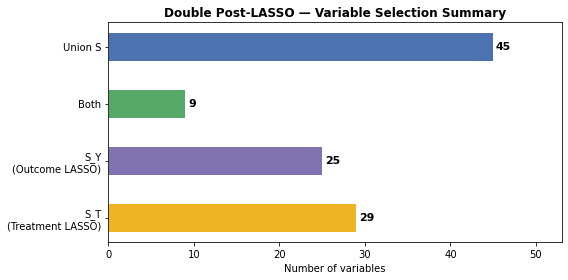

In [125]:
fig, ax = plt.subplots(figsize=(8, 4))
categories = ['S_T\n(Treatment LASSO)', 'S_Y\n(Outcome LASSO)', 'Both', 'Union S']
counts     = [len(selected_T), len(selected_Y), len(both), len(union_selected)]
colors     = ['#F0B323', '#8172B2', '#55A868', '#4C72B0']

bars = ax.barh(categories, counts, color=colors, edgecolor='white', height=0.5)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(cnt), va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Number of variables')
ax.set_title('Double Post-LASSO — Variable Selection Summary', fontweight='bold')
ax.set_xlim(0, max(counts) + 8)
plt.tight_layout()
plt.show()

## 6. Step 4 — Post-LASSO OLS (Linear Probability Model)

We regress **Dropout ~ Scholarship + union controls** using OLS with **HC3 heteroskedasticity-robust standard errors**.

The coefficient on `scholarship` is the **Average Treatment Effect (ATE)**: the average change in dropout probability associated with receiving a scholarship, conditional on the selected confounders.

> The LPM is the standard estimator in the Double Post-LASSO framework. It is consistent and its coefficient is directly interpretable as a percentage-point change in probability.

In [126]:
# Build regression dataframe with union-selected controls
X_union = X_scaled_df[union_selected].copy()
X_union.index = data.index

reg_df = pd.DataFrame({'dropout': Y, 'scholarship': T}, index=data.index).join(X_union)

# Sanitize column names for statsmodels formula interface
def sanitize(c):
    return (c.replace(' ', '_').replace('(', '').replace(')', '')
             .replace("'", '').replace('-', '_').replace('/', '_')
             .replace('\t', '').replace('.', ''))

rename_map    = {c: sanitize(c) for c in reg_df.columns}
reg_df        = reg_df.rename(columns=rename_map)
control_cols  = [c for c in reg_df.columns if c not in ['dropout', 'scholarship']]
formula_ols   = 'dropout ~ scholarship + ' + ' + '.join(control_cols)

# ── OLS with robust SE ──────────────────────────────────────────────────────
ols_model = smf.ols(formula_ols, data=reg_df).fit(cov_type='HC3')

ols_coef  = ols_model.params['scholarship']
ols_se    = ols_model.bse['scholarship']
ols_pval  = ols_model.pvalues['scholarship']
ols_ci    = ols_model.conf_int().loc['scholarship']

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                dropout   R-squared:                       0.520
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     212.6
Date:                Thu, 19 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:46:21   Log-Likelihood:                -1286.8
No. Observations:                4424   AIC:                             2668.
Df Residuals:                    4377   BIC:                             2968.
Df Model:                          46                                         
Covariance Type:                  HC3                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


## 7. Robustness Check — Post-LASSO Logit

The LPM can produce predicted probabilities outside [0, 1]. We verify the result with a **Logit model** on the same union control set.

**Singularity fix:** With many one-hot encoded dummies, perfect separation or near-collinearity can make standard Logit fail to converge. We address this by:
1. Using the already-cleaned feature matrix (zero-variance and perfectly collinear columns removed)
2. Fitting with `method='bfgs'` and a generous iteration budget
3. Falling back to `method='nm'` (Nelder-Mead) if BFGS fails
4. Reporting **Average Marginal Effects (AME)** for interpretability alongside log-odds

In [127]:
# ── Logit via statsmodels for proper inference & AME ──────────────────────
formula_logit = formula_ols  # same formula as OLS

fit_ok = False
for method in ['bfgs', 'lbfgs', 'nm']:
    try:
        logit_model = smf.logit(formula_logit, data=reg_df).fit(
            method=method, maxiter=500, disp=False
        )
        fit_ok = True
        print(f"Logit converged with method='{method}'")
        break
    except Exception as e:
        print(f"method='{method}' failed: {e}")

if not fit_ok:
    raise RuntimeError("Logit failed to converge with all methods. Check for separation or collinearity.")

print(logit_model.summary())

Logit converged with method='bfgs'
                           Logit Regression Results                           
Dep. Variable:                dropout   No. Observations:                 4424
Model:                          Logit   Df Residuals:                     4377
Method:                           MLE   Df Model:                           46
Date:                Thu, 19 Mar 2026   Pseudo R-squ.:                  0.4800
Time:                        16:46:21   Log-Likelihood:                -1444.3
converged:                       True   LL-Null:                       -2777.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                               -1.0486      1.004     -1.044      0.296      -3.016       0.919
scholarship       

In [134]:
print(ame.summary_frame().columns)

Index(['dy/dx', 'Std. Err.', 'z', 'Pr(>|z|)', 'Conf. Int. Low',
       'Cont. Int. Hi.'],
      dtype='object')


In [135]:
# ── Average Marginal Effects ───────────────────────────────────────────────
ame = logit_model.get_margeff()
print(ame.summary())

# Extract scholarship AME
ame_df        = ame.summary_frame()
logit_me      = ame_df.loc['scholarship', 'dy/dx']
logit_me_se   = ame_df.loc['scholarship', 'Std. Err.']
logit_me_pval = ame_df.loc['scholarship', 'Pr(>|z|)']
logit_me_ci   = (ame_df.loc['scholarship', 'Conf. Int. Low'],
                 ame_df.loc['scholarship', 'Cont. Int. Hi.'])

        Logit Marginal Effects       
Dep. Variable:                dropout
Method:                          dydx
At:                           overall
                                          dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
scholarship                             -0.0582      0.014     -4.228      0.000      -0.085      -0.031
Gender                                   0.0127      0.005      2.556      0.011       0.003       0.022
Application_mode_7                       0.0148      0.005      2.865      0.004       0.005       0.025
Application_mode_15                     -0.0103      0.006     -1.861      0.063      -0.021       0.001
Mothers_occupation_7                     0.0006      0.005      0.102      0.919      -0.010       0.011
Course_9991                              0.0056      0.005      1.154      0.248      -0.004       0.015
Fathers_

## 8. Results Summary

In [136]:
print("=" * 62)
print("     DOUBLE POST-LASSO — MAIN RESULTS")
print("=" * 62)
print(f"  Treatment  : Scholarship holder")
print(f"  Outcome    : Dropout (binary)")
print(f"  N          : {len(reg_df):,}")
print(f"  Controls   : {len(union_selected)} selected by Double Post-LASSO (union)")
print()
print(f"  ── OLS / Linear Probability Model (HC3 robust SE) ──")
print(f"  ATE         = {ols_coef:+.4f}")
print(f"  Std. Error  = {ols_se:.4f}")
print(f"  p-value     = {ols_pval:.4f}")
print(f"  95% CI      = [{ols_ci[0]:+.4f}, {ols_ci[1]:+.4f}]")
print()
print(f"  ── Logit — Average Marginal Effect ─────────────────")
print(f"  AME         = {logit_me:+.4f}")
print(f"  Std. Error  = {logit_me_se:.4f}")
print(f"  p-value     = {logit_me_pval:.4f}")
print(f"  95% CI      = [{logit_me_ci[0]:+.4f}, {logit_me_ci[1]:+.4f}]")
print()
print("=" * 62)

direction = "NEGATIVE" if ols_coef < 0 else "POSITIVE"
sig       = "statistically significant (p < 0.05)" if ols_pval < 0.05 else "NOT significant (p ≥ 0.05)"
print(f"\n  ➜ Effect of scholarship on dropout: {direction}, {sig}")
if ols_coef < 0 and ols_pval < 0.05:
    print(f"  ✅ Hypothesis SUPPORTED — scholarship reduces P(dropout)")
    print(f"     by ≈ {abs(ols_coef)*100:.1f} pp on average (OLS).")
else:
    print(f"  ❌ Hypothesis NOT supported at the 5% level.")

     DOUBLE POST-LASSO — MAIN RESULTS
  Treatment  : Scholarship holder
  Outcome    : Dropout (binary)
  N          : 4,424
  Controls   : 45 selected by Double Post-LASSO (union)

  ── OLS / Linear Probability Model (HC3 robust SE) ──
  ATE         = -0.0502
  Std. Error  = 0.0118
  p-value     = 0.0000
  95% CI      = [-0.0733, -0.0271]

  ── Logit — Average Marginal Effect ─────────────────
  AME         = -0.0582
  Std. Error  = 0.0138
  p-value     = 0.0000
  95% CI      = [-0.0852, -0.0312]


  ➜ Effect of scholarship on dropout: NEGATIVE, statistically significant (p < 0.05)
  ✅ Hypothesis SUPPORTED — scholarship reduces P(dropout)
     by ≈ 5.0 pp on average (OLS).


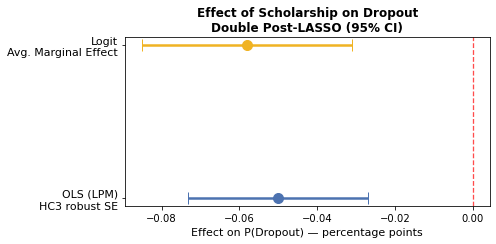

In [137]:
fig, ax = plt.subplots(figsize=(7, 3.5))

estimates = [ols_coef,  logit_me]
errors    = [ols_se,    logit_me_se]
labels    = ['OLS (LPM)\nHC3 robust SE', 'Logit\nAvg. Marginal Effect']
colors    = ['#4C72B0', '#F0B323']

for i, (est, se, label, color) in enumerate(zip(estimates, errors, labels, colors)):
    ax.errorbar(est, i, xerr=se * 1.96, fmt='o', color=color,
                capsize=6, markersize=10, linewidth=2.5)

ax.axvline(0, color='red', linestyle='--', linewidth=1.3, alpha=0.7)
ax.set_yticks([0, 1])
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Effect on P(Dropout) — percentage points', fontsize=11)
ax.set_title('Effect of Scholarship on Dropout\nDouble Post-LASSO (95% CI)', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Sensitivity Checks

### 9.1 Naive OLS vs Post-LASSO OLS

We compare the raw bivariate estimate (no controls) to the Double Post-LASSO estimate to quantify the omitted-variable bias removed by the procedure.

### 9.2 Controlling for Mediators (misspecified model)

By including `Debtor` and `Tuition fees up to date` as controls, we demonstrate the **post-treatment bias** that arises when mediators are incorrectly added to the regression. The shift in the scholarship coefficient relative to the correct specification quantifies how much of the scholarship effect operates through financial constraints.

In [131]:
# ── 9.1 Naive OLS ────────────────────────────────────────────────────────
naive_model = smf.ols('dropout ~ scholarship', data=reg_df).fit(cov_type='HC3')
naive_coef  = naive_model.params['scholarship']
naive_se    = naive_model.bse['scholarship']
naive_pval  = naive_model.pvalues['scholarship']

print("9.1 — Naive OLS vs Double Post-LASSO OLS")
print("-" * 52)
print(f"  Naive OLS (no controls)   : β = {naive_coef:+.4f}  SE={naive_se:.4f}  p={naive_pval:.4f}")
print(f"  Post-LASSO OLS            : β = {ols_coef:+.4f}  SE={ols_se:.4f}  p={ols_pval:.4f}")
print(f"  OVB removed by LASSO      : {naive_coef - ols_coef:+.4f}")

# ── 9.2 Mediators ─────────────────────────────────────────────────────────
print()
mediators           = ['Debtor', 'Tuition fees up to date']
available_mediators = [m for m in mediators if m in df.columns]

if available_mediators:
    reg_df_med = reg_df.copy()
    for m in available_mediators:
        safe = sanitize(m)
        reg_df_med[safe] = df.loc[data.index, m].values

    formula_med = formula_ols + ' + ' + ' + '.join([sanitize(m) for m in available_mediators])
    model_med   = smf.ols(formula_med, data=reg_df_med).fit(cov_type='HC3')
    coef_med    = model_med.params['scholarship']

    print("9.2 — Post-treatment bias when mediators are incorrectly controlled")
    print("-" * 65)
    print(f"  Correct (no mediators) : β = {ols_coef:+.4f}")
    print(f"  With mediators         : β = {coef_med:+.4f}")
    print(f"  Post-treatment bias    : {coef_med - ols_coef:+.4f}")
    print("  → Part of the scholarship effect operates through financial constraints.")
else:
    print("Mediator columns not found — check column names.")

9.1 — Naive OLS vs Double Post-LASSO OLS
----------------------------------------------------
  Naive OLS (no controls)   : β = -0.2651  SE=0.0130  p=0.0000
  Post-LASSO OLS            : β = -0.0502  SE=0.0118  p=0.0000
  OVB removed by LASSO      : -0.2150

9.2 — Post-treatment bias when mediators are incorrectly controlled
-----------------------------------------------------------------
  Correct (no mediators) : β = -0.0502
  With mediators         : β = -0.0429
  Post-treatment bias    : +0.0073
  → Part of the scholarship effect operates through financial constraints.


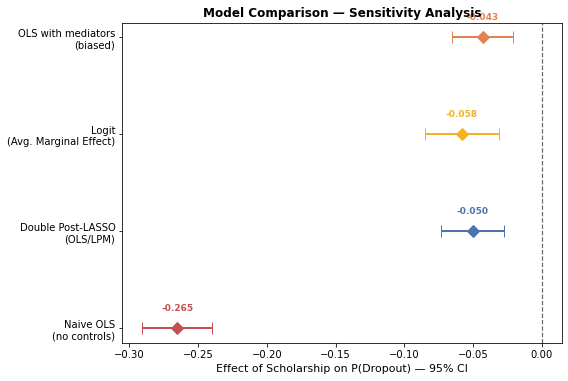

In [132]:
# ── Comparison plot ──────────────────────────────────────────────────────
models_comparison = {
    'Naive OLS\n(no controls)':      (naive_coef, naive_se),
    'Double Post-LASSO\n(OLS/LPM)': (ols_coef,   ols_se),
    'Logit\n(Avg. Marginal Effect)': (logit_me,   logit_me_se),
}
if available_mediators:
    models_comparison["OLS with mediators\n(biased)"] = (coef_med, model_med.bse['scholarship'])

fig, ax = plt.subplots(figsize=(8, 1 + len(models_comparison) * 1.1))
palette = ['#C44E52', '#4C72B0', '#F0B323', '#DD8452']

for i, (label, (est, se)) in enumerate(models_comparison.items()):
    ax.errorbar(est, i, xerr=se * 1.96, fmt='D', color=palette[i],
                capsize=6, markersize=9, linewidth=2)
    ax.text(est, i + 0.18, f'{est:+.3f}', ha='center', fontsize=9, color=palette[i], fontweight='bold')

ax.axvline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
ax.set_yticks(range(len(models_comparison)))
ax.set_yticklabels(list(models_comparison.keys()), fontsize=10)
ax.set_xlabel('Effect of Scholarship on P(Dropout) — 95% CI', fontsize=11)
ax.set_title('Model Comparison — Sensitivity Analysis', fontweight='bold')
plt.tight_layout()
plt.show()